# Network Graph
### In Networkx, a graph is essentially nodes and edges.
Nodes: It is a location or a point in a network
 - In this project, the nodes are substaions
Edges: It is a connection between two nodes
 - In this project, the edges are transmission lines

 We have 44 nodes connected by 55 edges

 ### Networkx Graph Types
 #### There are four types; directed graph, undirected graph. multidirected graph and multiundirected graph.
 - In this project, we will use undirected graph because AC (Alternating power) can flow in either direction along
 a line depending on the system conditions. 
 - Thus, we just need a connection, not a direction.

In [115]:
%pip install networkx


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [116]:
# Importing Networkx

import networkx as nx 
import matplotlib.pyplot as plt 

G = nx.Graph()

print(G.number_of_nodes())    # 0 , since no nodes have being added
print(G.number_of_edges())   

0
0


In [117]:
#   Loading the substations dataset
import pandas as pd 
substations = pd.read_csv("../data/substations.csv")
substations.head(3)

,Substation ID,Name,Short Name,Region,Country,Latitude,Longitude,Voltage (kV),Capacity (MVA),Commissioning Year,Type,Status
0,1,Achimota Substation,Achimota,Greater Accra,Ghana,5.6085,-0.2193,11,6.4,2008,Distribution,Active
1,2,Tema Substation,Tema,Greater Accra,Ghana,5.6596,-0.0226,330,48.5,1997,Transmission,Active
2,3,Mallam Substation,Mallam,Greater Accra,Ghana,5.5630,-0.2971,330,25.2,1979,Transmission,Active


In [118]:
# Adding the nodes to the networkx graph

G.add_nodes_from(substations['Substation ID'])
print(f" Number of nodes: {G.number_of_nodes()}")    
print(f" Number of edges: {G.number_of_edges()}")   # still 0, since no edges exist now

 Number of nodes: 44
 Number of edges: 0


In [119]:
# processed_data is same as the lines_complete dataset

lines_complete = pd.read_csv("processed_data.csv", index_col=0)
lines_complete.head(3)
# print(lines_complete.columns)

,Utility ID,Source Substation ID,Source Substation,Destination Substation ID,Destination Substation,Line Voltage (kV),Line Length (km),Line Capacity (MVA),Line Status,Line Type,...,Destination Short Name,Destination Region,Destination Country,Destination Latitude,Destination Longitude,Destination Voltage (kV),Destination Capacity (MVA),Destination Commissioning Year,Destination Type,Destination Status
Line ID,,,,,,,,,,,,,,,,,,,,,
1,2,1,Achimota Substation,2,Tema Substation,11,25.2,215.0,Active,Underground,...,Tema,Greater Accra,Ghana,5.6596,-0.0226,330,48.5,1997,Transmission,Active
2,2,1,Achimota Substation,3,Mallam Substation,11,11.0,36.4,Active,Overhead,...,Mallam,Greater Accra,Ghana,5.5630,-0.2971,330,25.2,1979,Transmission,Active
3,3,1,Achimota Substation,5,Kaneshie Substation,11,5.9,277.4,Active,Overhead,...,Kaneshie,Greater Accra,Ghana,5.5691,-0.2413,161,146.0,1970,Transmission,Active


In [120]:
# Adding edges or forming edges between source node and destination node
'''
Go through each row in the processed_data ( lines_complete dataset), for each row
add an edge between the source substation id and the destination substations id
'''
for _,row in lines_complete.iterrows():
    G.add_edge(
        row['Source Substation ID'],
        row['Destination Substation ID']
        )

print(f" Number of nodes: {G.number_of_nodes()}")    
print(f" Number of edges: {G.number_of_edges()}")

 Number of nodes: 44
 Number of edges: 55


In [121]:
set(G.nodes) - set(substations['Substation ID'])

set()

In [122]:
# Adding specific attributes of each node( or substation) to the networkx

for _, row in substations.iterrows():
    G.nodes[row["Substation ID"]]["Name"] = row['Name']
    G.nodes[row["Substation ID"]]["Region"] = row["Region"]
    G.nodes[row["Substation ID"]]["Voltage"] = row["Voltage (kV)"]
    G.nodes[row["Substation ID"]]["Capacity"] = row["Capacity (MVA)"]
    G.nodes[row["Substation ID"]]["Coordinate"] = row[["Latitude","Longitude"]]

#  inspecting random nodes to verify if attrinutes has ben added     
print(G.nodes[9])
print(G.nodes[23])

# Inspect all nodes
# G.nodes(data=True)

{'Name': 'Obuasi Substation', 'Region': 'Ashanti', 'Voltage': 33, 'Capacity': 47.5, 'Coordinate': Latitude     6.2091
Longitude   -1.6557
Name: 8, dtype: object}
{'Name': 'Suhum Substation', 'Region': 'Eastern', 'Voltage': 69, 'Capacity': 339.0, 'Coordinate': Latitude      6.035
Longitude   -0.4535
Name: 22, dtype: object}


In [123]:
print(G.edges)
# Adding specific attributes to the edges( transmission lines)

for _,row in lines_complete.iterrows():
    G.edges[row["Source Substation ID"],row["Destination Substation ID"]]["Length"] = row['Line Length (km)']
    G.edges[row["Source Substation ID"],row["Destination Substation ID"]]["Voltage"] = row['Line Voltage (kV)']
    G.edges[row["Source Substation ID"],row["Destination Substation ID"]]["Capacity"] = row['Line Capacity (MVA)']
    G.edges[row["Source Substation ID"],row["Destination Substation ID"]]["Status"] = row['Line Status']
    G.edges[row["Source Substation ID"],row["Destination Substation ID"]]["Type"] = row['Line Type']

#  inspecting random edges to verify if attrinutes has ben added 
print(G.edges[1,2])
print(G.edges[7,10])

# inspect all edges
G.edges(data=True)


[(1, 2), (1, 3), (1, 5), (1, 7), (2, 3), (2, 4), (2, 39), (3, 4), (3, 5), (3, 6), (4, 5), (4, 6), (7, 10), (7, 11), (7, 12), (7, 38), (8, 9), (8, 11), (9, 11), (10, 11), (12, 13), (12, 14), (12, 16), (13, 14), (13, 15), (14, 15), (16, 17), (16, 18), (16, 19), (16, 20), (17, 18), (18, 19), (20, 21), (20, 22), (20, 24), (21, 22), (21, 23), (22, 23), (24, 25), (24, 27), (24, 28), (25, 27), (26, 27), (28, 29), (28, 31), (29, 30), (31, 32), (31, 34), (34, 35), (34, 36), (34, 37), (37, 43), (38, 42), (39, 40), (40, 41)]
{'Length': 25.2, 'Voltage': 11, 'Capacity': 215.0, 'Status': 'Active', 'Type': 'Underground'}
{'Length': 53.3, 'Voltage': 69, 'Capacity': 269.1, 'Status': 'Active', 'Type': 'Overhead'}


EdgeDataView([(1, 2, {'Length': 25.2, 'Voltage': 11, 'Capacity': 215.0, 'Status': 'Active', 'Type': 'Underground'}), (1, 3, {'Length': 11.0, 'Voltage': 11, 'Capacity': 36.4, 'Status': 'Active', 'Type': 'Overhead'}), (1, 5, {'Length': 5.9, 'Voltage': 11, 'Capacity': 277.4, 'Status': 'Active', 'Type': 'Overhead'}), (1, 7, {'Length': 225.4, 'Voltage': 330, 'Capacity': 303.7, 'Status': 'Active', 'Type': 'Overhead'}), (2, 3, {'Length': 34.4, 'Voltage': 330, 'Capacity': 39.0, 'Status': 'Active', 'Type': 'Underground'}), (2, 4, {'Length': 19.5, 'Voltage': 161, 'Capacity': 186.5, 'Status': 'Active', 'Type': 'Underground'}), (2, 39, {'Length': 157.9, 'Voltage': 330, 'Capacity': 207.8, 'Status': 'Active', 'Type': 'Overhead'}), (3, 4, {'Length': 17.1, 'Voltage': 161, 'Capacity': 220.5, 'Status': 'Active', 'Type': 'Underground'}), (3, 5, {'Length': 7.0, 'Voltage': 161, 'Capacity': 108.5, 'Status': 'Active', 'Type': 'Overhead'}), (3, 6, {'Length': 22.4, 'Voltage': 161, 'Capacity': 298.9, 'Status': 

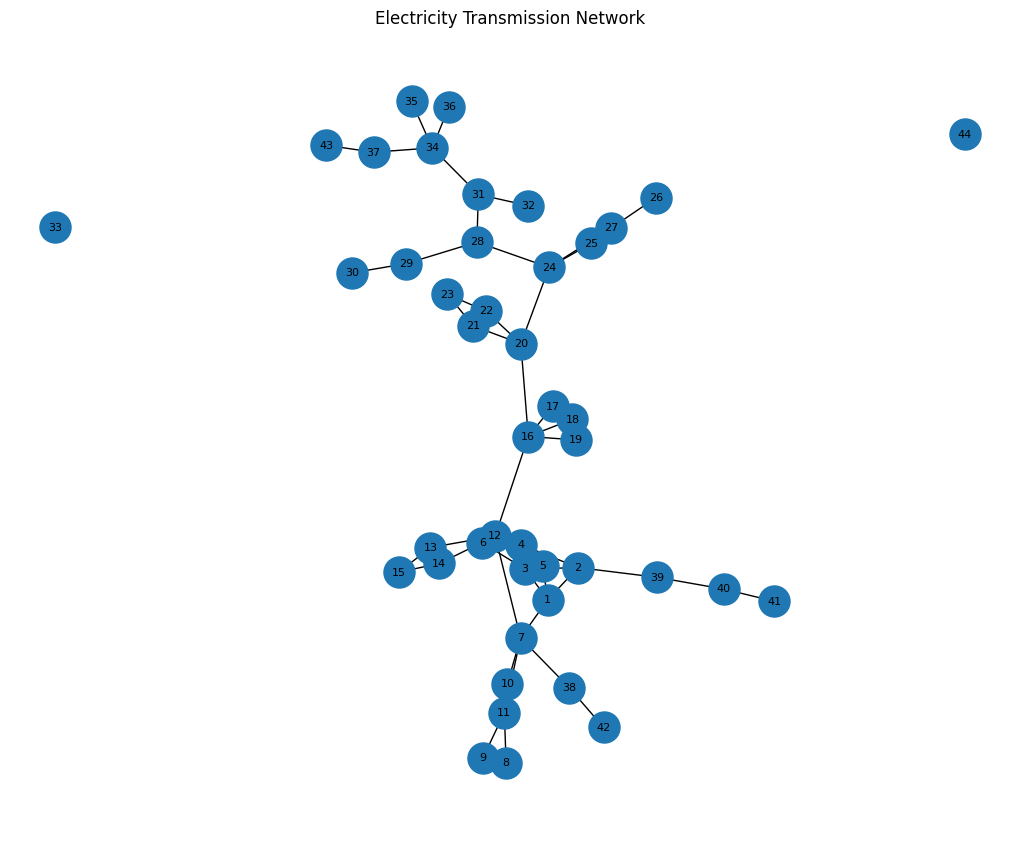

In [124]:
# Visualizing the graph

plt.figure(figsize=(10,8))     # controls the size of the graph interface making it clear

# Creating artificial positions of the nodes based on how they are connected 
positions = nx.spring_layout(G, seed=42)

# Drawing the network using the positions

nx.draw(G,                     # graph built
positions,                     # coordinates of the nodes
with_labels= True,             # shows the substations or nodes by their label
node_size= 500,                # makes the nodes big and visible
font_size= 8)                  # controls the fontsize of the label

plt.title('Electricity Transmission Network')
plt.show()

The network visualization shows that most substations form a connected structure, while nodes 33 and 44 appear isolated with no visible transmission-line connection